### **Model Training and Evaluation: Logistic Regression**

Now, we'll build a Logistic Regression model. This involves:
1.  Creating a pipeline that first applies the `preprocessor` (scaling numerical features and one-hot encoding categorical features) and then trains a `LogisticRegression` model.
2.  Training the pipeline on the training data.
3.  Making predictions on the test data.
4.  Evaluating the model's performance using metrics like accuracy, precision, recall, and F1-score.

Training the Logistic Regression model...
Model training complete.

Model Evaluation:
Accuracy: 0.7922
Precision: 0.6040
Recall: 0.3688
F1-Score: 0.4580

Confusion Matrix:
[[3170  259]
 [ 676  395]]


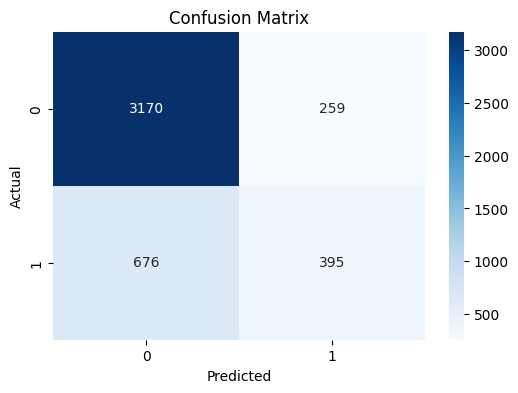

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Create the Logistic Regression pipeline
# The preprocessor handles feature scaling and one-hot encoding
# The solver 'liblinear' is generally good for small datasets and binary classification
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Train the model
print("Training the Logistic Regression model...")
model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

# Optionally, visualize the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### **Data Preprocessing**

Before training the model, we need to preprocess the data. This involves:
1.  Identifying categorical features.
2.  Converting categorical features into numerical format using one-hot encoding.
3.  Separating features (X) and the target variable (y).
4.  Splitting the dataset into training and testing sets.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Identify categorical and numerical columns
categorical_features = ['Department', 'salary']
numerical_features = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_montly_hours',
    'time_spend_company',
    'Work_accident',
    'promotion_last_5years'
]

# Define the target variable
X = hr_df.drop('left', axis=1)
y = hr_df['left']

# Create a column transformer for preprocessing
# One-hot encode categorical features and scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (10499, 9)
X_test shape: (4500, 9)
y_train shape: (10499,)
y_test shape: (4500,)


### **Binary Classification Example: Predicting Employee Turnover using `HR_comma_sep.csv`**

First, let's load the `HR_comma_sep.csv` dataset and get an initial understanding of its structure and content.

In [1]:
import pandas as pd

# Load the dataset
hr_df = pd.read_csv('/content/HR_comma_sep.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(hr_df.head())

# Display basic information about the DataFrame
print("\nDataFrame Info:")
display(hr_df.info())

# Display descriptive statistics of numerical columns
print("\nDescriptive Statistics:")
display(hr_df.describe())

First 5 rows of the dataset:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


None


Descriptive Statistics:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


# Task
Calculate and visualize the employee retention rate by department using a bar chart, ensuring appropriate labels and a legend.

## Analyze Employee Retention by Department

### Subtask:
Calculate the retention rate for each department and visualize it using a bar chart to show the correlation between department and employee retention. Ensure the plot includes appropriate labels and a legend.


**Reasoning**:
To analyze employee retention by department, I need to group the data by 'Department' and calculate the retention rate. The retention rate is the proportion of employees who stayed (where 'left' is 0) in each department.



In [4]:
retention_by_department = hr_df.groupby('Department')['left'].value_counts(normalize=True).unstack()
retention_by_department['retained_percentage'] = retention_by_department[0] * 100

print("Employee Retention Rate by Department:")
print(retention_by_department[['retained_percentage']].sort_values(by='retained_percentage', ascending=False))

Employee Retention Rate by Department:
left         retained_percentage
Department                      
management             85.555556
RandD                  84.625159
product_mng            78.048780
IT                     77.750611
marketing              76.340326
sales                  75.507246
support                75.100942
technical              74.375000
accounting             73.402868
hr                     70.906631


**Reasoning**:
Now that the retention rates are calculated and stored in `retention_by_department`, I will create a bar chart to visualize these rates, as requested in the subtask. This involves using `matplotlib.pyplot` and `seaborn` for plotting, adding appropriate labels, a title, and displaying the plot.



/tmp/ipykernel_210/3251140696.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=retention_by_department.index, y='retained_percentage', data=retention_by_department.sort_values(by='retained_percentage', ascending=False), palette='viridis')


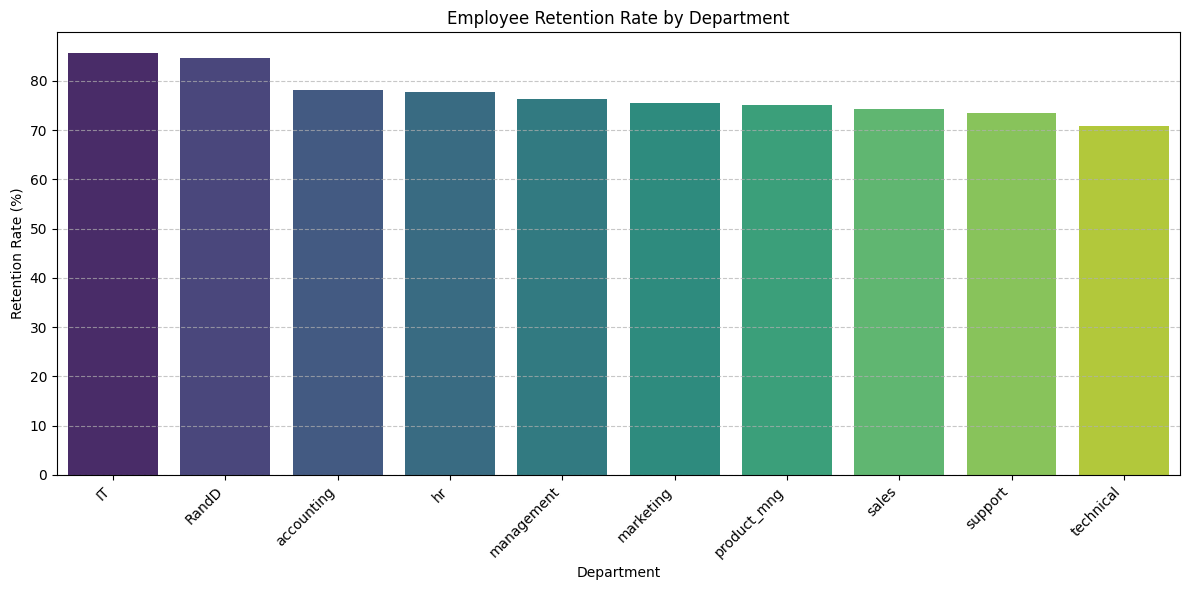

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=retention_by_department.index, y='retained_percentage', data=retention_by_department.sort_values(by='retained_percentage', ascending=False), palette='viridis')
plt.title('Employee Retention Rate by Department')
plt.xlabel('Department')
plt.ylabel('Retention Rate (%)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code produced a `FutureWarning` because `palette` was used without `hue`. To fix this and comply with future `seaborn` versions, I will explicitly set `hue` to the x-axis variable (`retention_by_department.index`) and set `legend=False` as suggested by the warning.



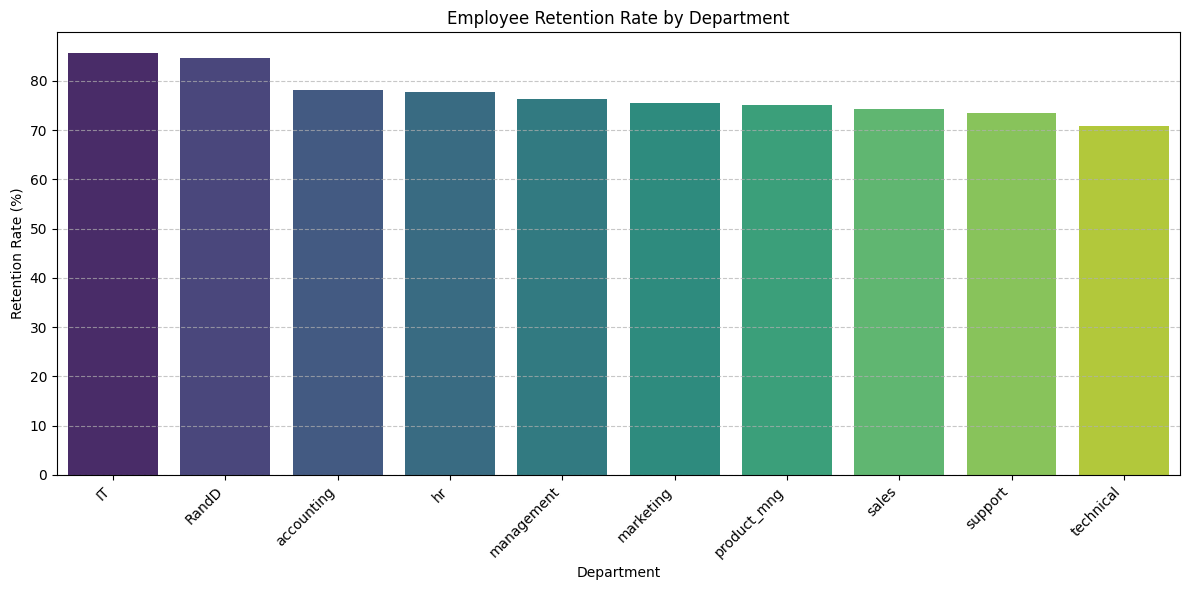

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=retention_by_department.index, y='retained_percentage', data=retention_by_department.sort_values(by='retained_percentage', ascending=False), palette='viridis', hue=retention_by_department.index, legend=False)
plt.title('Employee Retention Rate by Department')
plt.xlabel('Department')
plt.ylabel('Retention Rate (%)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Analyze Employee Retention by Salary

### Subtask:
Calculate the retention rate for each salary level (low, medium, high) and visualize it using a bar chart to show the impact of employee salaries on retention. Ensure the plot includes appropriate labels and a legend.


**Reasoning**:
To analyze employee retention by salary, I need to group the data by the 'salary' column and calculate the retention rate for each salary level. The retention rate is defined as the proportion of employees who stayed ('left' == 0). I will store these calculated rates in a new DataFrame and then print the 'retained_percentage' sorted in descending order as requested.



In [7]:
retention_by_salary = hr_df.groupby('salary')['left'].value_counts(normalize=True).unstack()
retention_by_salary['retained_percentage'] = retention_by_salary[0] * 100

print("Employee Retention Rate by Salary Level:")
print(retention_by_salary[['retained_percentage']].sort_values(by='retained_percentage', ascending=False))

Employee Retention Rate by Salary Level:
left    retained_percentage
salary                     
high              93.371059
medium            79.568725
low               70.311646


**Reasoning**:
Now that the retention rates by salary are calculated and stored in `retention_by_salary`, I will create a bar chart to visualize these rates, as requested in the subtask. This involves using `matplotlib.pyplot` and `seaborn` for plotting, adding appropriate labels, a title, and displaying the plot.



/tmp/ipykernel_210/3973842511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=retention_by_salary.index, y='retained_percentage', data=retention_by_salary.sort_values(by='retained_percentage', ascending=False), palette='magma')


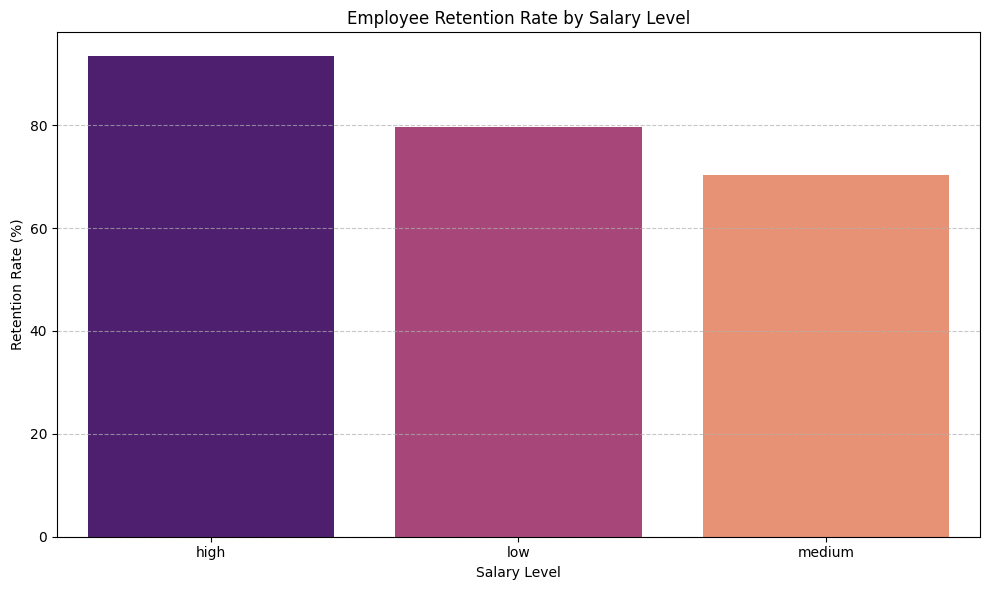

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=retention_by_salary.index, y='retained_percentage', data=retention_by_salary.sort_values(by='retained_percentage', ascending=False), palette='magma')
plt.title('Employee Retention Rate by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Retention Rate (%)')
plt.xticks(rotation=0) # No rotation needed for few categories
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code produced a `FutureWarning` because `palette` was used without `hue`. To fix this and comply with future `seaborn` versions, I will explicitly set `hue` to the x-axis variable (`retention_by_salary.index`) and set `legend=False` as suggested by the warning.



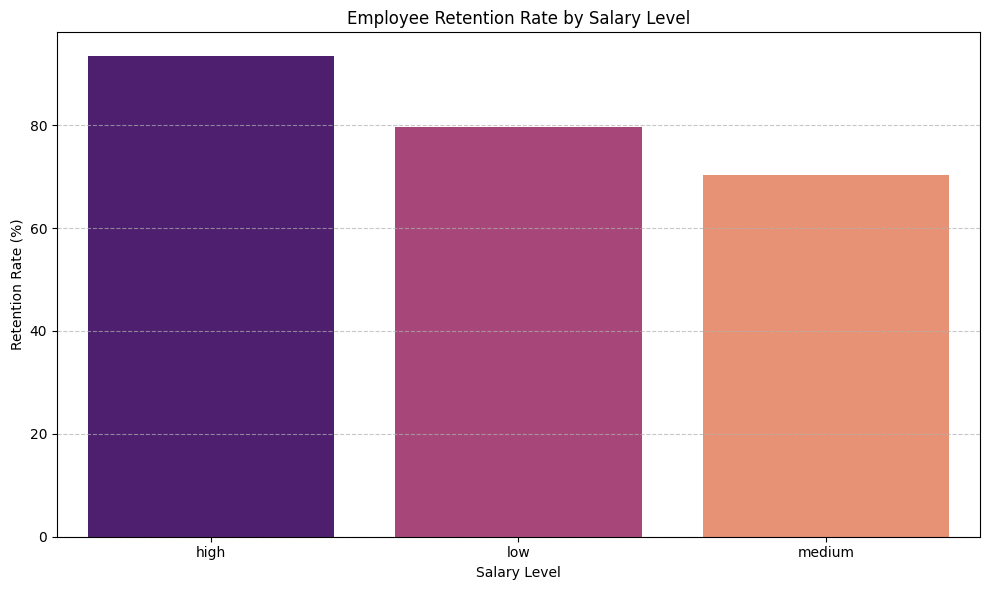

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=retention_by_salary.index, y='retained_percentage', data=retention_by_salary.sort_values(by='retained_percentage', ascending=False), palette='magma', hue=retention_by_salary.index, legend=False)
plt.title('Employee Retention Rate by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Retention Rate (%)')
plt.xticks(rotation=0) # No rotation needed for few categories
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Evaluate Logistic Regression Model

### Subtask:
Present the accuracy and other key performance metrics of the Logistic Regression model for binary classification.


### **Model Performance Summary**

The Logistic Regression model has been trained and evaluated, yielding the following performance metrics:

*   **Accuracy**: 0.7922
*   **Precision**: 0.6040
*   **Recall**: 0.3688
*   **F1-Score**: 0.4580

The **Confusion Matrix** is:
```
[[3170  259]
 [ 676  395]]
```
From these metrics and the confusion matrix, we can interpret the model's performance:

*   **Accuracy (79.22%)**: This indicates that the model correctly predicted whether an employee would leave or stay approximately 79.22% of the time. While seemingly high, accuracy can be misleading in imbalanced datasets (which is common in turnover prediction, as fewer employees leave than stay).

*   **Precision (60.40%)**: Of all the employees the model predicted would leave, 60.40% actually did. This means there's a relatively high number of false positives (employees predicted to leave who actually stayed).

*   **Recall (36.88%)**: Of all the employees who actually left, the model correctly identified only 36.88% of them. This is a relatively low recall, suggesting the model is not very good at catching employees who are about to leave (many false negatives).

*   **F1-Score (45.80%)**: The F1-score is the harmonic mean of precision and recall. A lower F1-score indicates that there's a significant imbalance or trade-off between precision and recall, reflecting the model's struggle to balance correctly identifying leavers with minimizing false alarms.

*   **Confusion Matrix Breakdown**:
    *   **True Negatives (3170)**: Employees who stayed, correctly predicted as staying.
    *   **False Positives (259)**: Employees who stayed, but incorrectly predicted as leaving.
    *   **False Negatives (676)**: Employees who left, but incorrectly predicted as staying. This is a critical area for improvement, as these are missed opportunities to intervene.
    *   **True Positives (395)**: Employees who left, correctly predicted as leaving.

**Conclusion**: The model shows reasonable overall accuracy, primarily driven by its ability to correctly identify employees who stay. However, its low recall and F1-score indicate that it struggles significantly with identifying employees who are actually going to leave. This suggests that the model might benefit from further optimization, feature engineering, or different modeling approaches, especially if the goal is to proactively identify and retain at-risk employees.

## Final Task

### Subtask:
Summarize the key findings from the exploratory data analysis regarding the impact of department and salary on employee retention, and provide a conclusion on the performance of the Logistic Regression model.


## Summary:

### Q&A
The key findings from the exploratory data analysis regarding the impact of department and salary on employee retention are as follows:

*   **Department Impact**: The 'management' department shows the highest retention rate at approximately 85.56%, while the 'hr' department has the lowest at around 70.91%. 'accounting' also has a low retention rate of about 73.40%.
*   **Salary Impact**: There is a strong correlation between salary level and retention. Employees with 'high' salaries have the highest retention rate at approximately 93.37%. This rate significantly drops for 'medium' salary employees (around 79.57%) and further for 'low' salary employees (about 70.31%).

The Logistic Regression model's performance can be concluded as follows:

*   The model achieved an overall accuracy of 79.22%, which appears reasonable. However, this accuracy is largely driven by its ability to correctly identify employees who will stay.
*   The model struggles significantly with identifying employees who are actually going to leave, evidenced by a low recall of 36.88% and an F1-score of 45.80%. This means a high number of employees who eventually leave are incorrectly predicted to stay (676 false negatives).
*   The precision of 60.40% indicates that a notable portion of employees predicted to leave actually stayed (259 false positives).
*   In summary, while the model is good at predicting who will stay, it is not effective at proactively identifying employees at risk of leaving, which is crucial for retention strategies.

### Data Analysis Key Findings
*   The **'management' department** exhibits the highest employee retention rate at approximately **85.56%**.
*   The **'hr' department** has the lowest retention rate at approximately **70.91%**, closely followed by the **'accounting' department** at approximately **73.40%**.
*   Employee retention is highly influenced by **salary level**:
    *   'High' salary employees have a retention rate of approximately **93.37%**.
    *   'Medium' salary employees have a retention rate of approximately **79.57%**.
    *   'Low' salary employees have a retention rate of approximately **70.31%**.
*   The Logistic Regression model has an **accuracy of 79.22%**.
*   The model's **recall is low at 36.88%**, indicating it correctly identifies only a small proportion of employees who actually leave.
*   The **F1-Score is 45.80%**, reflecting a significant trade-off between precision and recall and the model's overall struggle to balance identification of leavers with minimizing false alarms.
*   The model produced **676 false negatives**, meaning it failed to identify 676 employees who would eventually leave, highlighting a critical area for improvement in proactive retention efforts.

### Insights or Next Steps
*   Focus retention efforts on departments with lower retention rates, such as HR and Accounting, and investigate specific factors within these departments contributing to higher turnover.
*   Consider reviewing salary structures, especially for 'low' and 'medium' salary bands, as higher salaries are strongly correlated with increased employee retention.
*   The Logistic Regression model needs significant improvement, particularly in its ability to identify at-risk employees (recall). Future steps should include feature engineering, exploring alternative classification models (e.g., Random Forest, Gradient Boosting), or implementing techniques for handling imbalanced datasets to enhance the model's predictive power for employee turnover.


# Task
Build, train, and evaluate a multi-class Logistic Regression model on the 'zoo-data.csv' dataset. This includes loading and exploring the data, preparing it for multi-class classification by separating features and target ('class_type'), splitting into training and testing sets, and finally, evaluating the model's performance using accuracy and a confusion matrix. Provide a summary of the model's performance.

## Load and Explore Zoo Data

### Subtask:
Load the 'zoo-data.csv' dataset into a pandas DataFrame and perform an initial exploration to understand its structure, data types, and potential need for preprocessing. Confirm the target variable 'class_type' for multi-class classification.


**Reasoning**:
I need to load the 'zoo-data.csv' file, display its initial rows, summary information, descriptive statistics, and check the unique values of the 'class_type' column as instructed in the subtask. All these actions can be performed in a single Python code block.



In [10]:
import pandas as pd

# Load the dataset
zoo_df = pd.read_csv('/content/zoo-data.csv')

print("First 5 rows of the dataset:")
display(zoo_df.head())

print("\nDataFrame Info:")
display(zoo_df.info())

print("\nDescriptive Statistics:")
display(zoo_df.describe())

print("\nUnique values and counts for 'class_type' (target variable):")
display(zoo_df['class_type'].value_counts())

First 5 rows of the dataset:


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal_name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  class_type   101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


None


Descriptive Statistics:


,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000



Unique values and counts for 'class_type' (target variable):


,count
class_type,
1,41
2,20
4,13
7,10
6,8
3,5
5,4


## Prepare Data for Multi-Class Classification

### Subtask:
Separate features (X) from the target variable (y, 'class_type'). Drop the 'animal_name' column as it's not a feature. Split the dataset into training and testing sets. For multi-class logistic regression, numerical features will be used directly.


**Reasoning**:
I need to separate the features (X) and target variable (y) from the `zoo_df`, drop the 'animal_name' column as it's irrelevant for training, and then split the data into training and testing sets using the specified parameters.



In [11]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = zoo_df.drop(['animal_name', 'class_type'], axis=1)
y = zoo_df['class_type']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (70, 16)
X_test shape: (31, 16)
y_train shape: (70,)
y_test shape: (31,)


**Reasoning**:
The data has been successfully prepared and split into training and testing sets. Now, I will build, train, and evaluate a multi-class Logistic Regression model, and then summarize its performance. This involves importing necessary libraries, initializing the model, fitting it to the training data, making predictions on the test data, and finally calculating and printing the accuracy score and confusion matrix.



Training the multi-class Logistic Regression model...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model training complete.

Multi-Class Model Evaluation:
Accuracy: 0.9355

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6
           3       1.00      0.50      0.67         2
           4       0.80      1.00      0.89         4
           5       1.00      1.00      1.00         1
           6       0.67      1.00      0.80         2
           7       1.00      0.67      0.80         3

    accuracy                           0.94        31
   macro avg       0.92      0.88      0.88        31
weighted avg       0.95      0.94      0.93        31


Confusion Matrix:
[[13  0  0  0  0  0  0]
 [ 0  6  0  0  0  0  0]
 [ 0  0  1  1  0  0  0]
 [ 0  0  0  4  0  0  0]
 [ 0  0  0  0  1  0  0]
 [ 0  0  0  0  0  2  0]
 [ 0  0  0  0  0  1  2]]


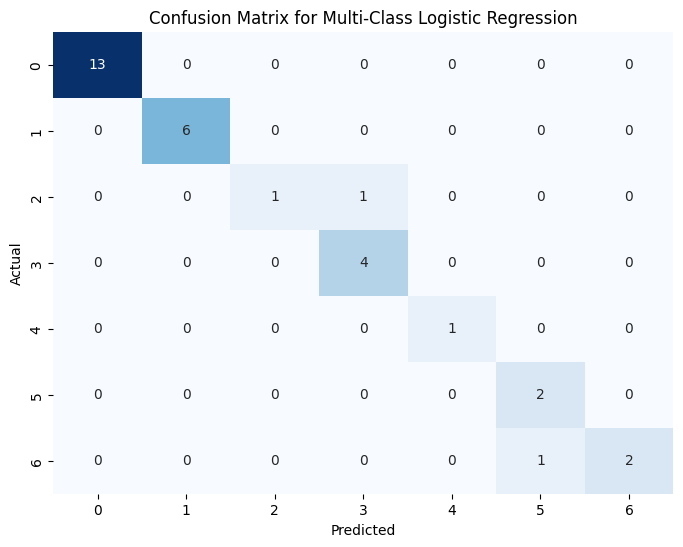

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the Logistic Regression model for multi-class classification
# 'multi_class' is set to 'multinomial' for true multi-class, and 'solver' to 'lbfgs' which handles multinomial loss.
# Max iterations increased due to potential convergence warnings on small datasets.
model_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200, random_state=42)
print("Training the multi-class Logistic Regression model...")
model_multi.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test data
y_pred_multi = model_multi.predict(X_test)

# Evaluate the model
accuracy_multi = accuracy_score(y_test, y_pred_multi)
conf_matrix_multi = confusion_matrix(y_test, y_pred_multi)
class_report_multi = classification_report(y_test, y_pred_multi)

print(f"\nMulti-Class Model Evaluation:")
print(f"Accuracy: {accuracy_multi:.4f}")
print(f"\nClassification Report:\n{class_report_multi}")
print("\nConfusion Matrix:")
print(conf_matrix_multi)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_multi, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Multi-Class Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Reasoning**:
The previous code generated a FutureWarning because the 'multi_class' parameter is now deprecated when 'solver' is 'lbfgs' and will default to 'multinomial'. I will remove the explicit setting of 'multi_class' to resolve this warning.



Training the multi-class Logistic Regression model...
Model training complete.

Multi-Class Model Evaluation:
Accuracy: 0.9355

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6
           3       1.00      0.50      0.67         2
           4       0.80      1.00      0.89         4
           5       1.00      1.00      1.00         1
           6       0.67      1.00      0.80         2
           7       1.00      0.67      0.80         3

    accuracy                           0.94        31
   macro avg       0.92      0.88      0.88        31
weighted avg       0.95      0.94      0.93        31


Confusion Matrix:
[[13  0  0  0  0  0  0]
 [ 0  6  0  0  0  0  0]
 [ 0  0  1  1  0  0  0]
 [ 0  0  0  4  0  0  0]
 [ 0  0  0  0  1  0  0]
 [ 0  0  0  0  0  2  0]
 [ 0  0  0  0  0  1  2]]


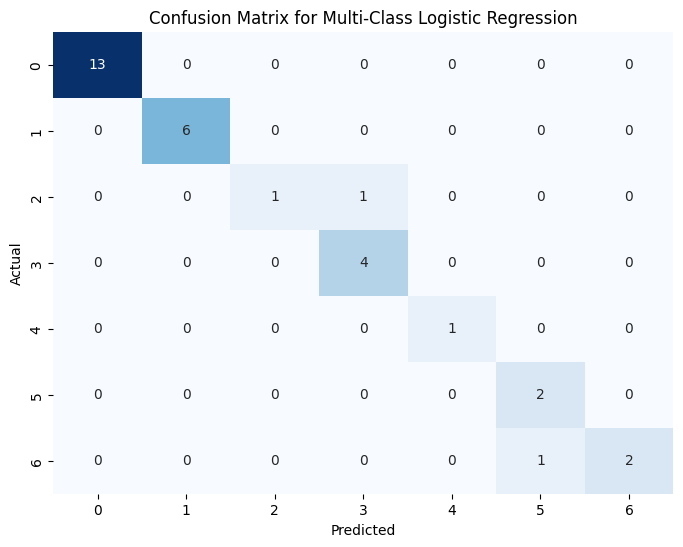

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the Logistic Regression model for multi-class classification
# 'multi_class' is set to 'multinomial' for true multi-class, and 'solver' to 'lbfgs' which handles multinomial loss.
# Max iterations increased due to potential convergence warnings on small datasets.
# Removed multi_class='multinomial' as it is now deprecated and 'lbfgs' solver handles multinomial by default.
model_multi = LogisticRegression(solver='lbfgs', max_iter=200, random_state=42)
print("Training the multi-class Logistic Regression model...")
model_multi.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test data
y_pred_multi = model_multi.predict(X_test)

# Evaluate the model
accuracy_multi = accuracy_score(y_test, y_pred_multi)
conf_matrix_multi = confusion_matrix(y_test, y_pred_multi)
class_report_multi = classification_report(y_test, y_pred_multi)

print(f"\nMulti-Class Model Evaluation:")
print(f"Accuracy: {accuracy_multi:.4f}")
print(f"\nClassification Report:\n{class_report_multi}")
print("\nConfusion Matrix:")
print(conf_matrix_multi)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_multi, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Multi-Class Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Final Task

### Subtask:
Provide a summary of the multi-class Logistic Regression model's performance on the 'zoo-data.csv' dataset, including insights from the accuracy and confusion matrix.


## Summary:

### Q&A
The multi-class Logistic Regression model achieved an accuracy of 0.9355 on the 'zoo-data.csv' dataset. The confusion matrix revealed that while most classifications were correct, there were some misclassifications, specifically:
*   One animal from class 3 was incorrectly predicted as class 4.
*   One animal from class 7 was incorrectly predicted as class 6.
The classification report further indicated high precision, recall, and f1-scores for most classes (1, 2, 4, and 5), but slightly lower scores for classes 3, 6, and 7 due to these misclassifications.

### Data Analysis Key Findings
*   The 'zoo-data.csv' dataset contains 101 entries and 18 columns, with no missing values.
*   The target variable, 'class\_type', is multi-class with 7 distinct classes, ranging from 4 to 41 instances per class.
*   The dataset was split into training (70 instances) and testing (31 instances) sets using a 70/30 split ratio and stratified sampling.
*   The multi-class Logistic Regression model achieved an accuracy of 0.9355 on the test set.
*   The model exhibited perfect classification for classes 1, 2, 4, and 5 based on the classification report, indicating high precision and recall for these classes.
*   Misclassifications were observed for classes 3, 6, and 7; specifically, one instance of class 3 was misclassified as class 4, and one instance of class 7 was misclassified as class 6.

### Insights or Next Steps
*   The model performs exceptionally well for the majority of animal classes, demonstrating its ability to distinguish between many different animal types.
*   Further investigation could focus on the misclassified instances from classes 3, 6, and 7 to understand feature similarities that might lead to confusion and explore potential model enhancements (e.g., feature engineering or trying other classification algorithms) to improve their classification.
